In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files

uploaded = files.upload()

# Replace with your actual filename
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
df.head()

Saving Dataset.csv to Dataset.csv


,gender,weight_kg,height,waist,hip,chest,shoulder-breadth,wrist
0,1,56.85,170.853062,73.248109,94.626127,81.691978,33.810283,14.506988
1,0,52.75,164.230293,68.504955,85.631847,88.711399,34.969699,15.157094
2,0,80.00,172.555771,90.152718,103.848091,107.267212,38.381180,17.260105
3,0,73.85,178.774821,82.100598,99.342301,100.673547,36.059983,17.086464
4,0,73.80,179.717860,89.971087,97.628494,107.578957,37.451279,16.362741


In [ ]:
required_cols = [
    "gender",
    "weight_kg",
    "height",
    "waist",
    "hip",
    "chest",
    "shoulder-breadth",
    "wrist"
]

df = df[required_cols]
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2504 entries, 0 to 2503
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            2504 non-null   int64  
 1   weight_kg         2504 non-null   float64
 2   height            2504 non-null   float64
 3   waist             2504 non-null   float64
 4   hip               2504 non-null   float64
 5   chest             2504 non-null   float64
 6   shoulder-breadth  2504 non-null   float64
 7   wrist             2504 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 156.6 KB


In [ ]:
# Convert height to meters
df["height_m"] = df["height"] / 100

# Core metrics
df["BMI"] = df["weight_kg"] / (df["height_m"] ** 2)

# Ratios
df["WaistHipRatio"] = df["waist"] / df["hip"]
df["ShoulderWaistRatio"] = df["shoulder-breadth"] / df["waist"]
df["ChestWaistRatio"] = df["chest"] / df["waist"]
df["HeightWaistRatio"] = df["height"] / df["waist"]
df["FrameIndex"] = df["height"] / df["wrist"]

df.head()


,gender,weight_kg,height,waist,hip,chest,shoulder-breadth,wrist,height_m,BMI,WaistHipRatio,ShoulderWaistRatio,ChestWaistRatio,HeightWaistRatio,FrameIndex
0,1,56.85,170.853062,73.248109,94.626127,81.691978,33.810283,14.506988,1.708531,19.475335,0.774079,0.461586,1.115278,2.332525,11.777294
1,0,52.75,164.230293,68.504955,85.631847,88.711399,34.969699,15.157094,1.642303,19.557617,0.799994,0.510470,1.294963,2.397349,10.835210
2,0,80.00,172.555771,90.152718,103.848091,107.267212,38.381180,17.260105,1.725558,26.867732,0.868121,0.425735,1.189839,1.914038,9.997377
3,0,73.85,178.774821,82.100598,99.342301,100.673547,36.059983,17.086464,1.787748,23.106693,0.826441,0.439217,1.226222,2.177509,10.462950
4,0,73.80,179.717860,89.971087,97.628494,107.578957,37.451279,16.362741,1.797179,22.849352,0.921566,0.416259,1.195706,1.997507,10.983359


In [ ]:
def normalize(col):
    return (col - col.mean()) / col.std()

for col in [
    "BMI",
    "WaistHipRatio",
    "ShoulderWaistRatio",
    "ChestWaistRatio",
    "HeightWaistRatio",
    "FrameIndex"
]:
    df[col + "_n"] = normalize(df[col])


In [ ]:
df["EndomorphScore"] = (
    0.5 * df["BMI_n"] +
    0.3 * df["WaistHipRatio_n"] -
    0.2 * df["HeightWaistRatio_n"]
)

df["MesomorphScore"] = (
    0.4 * df["ShoulderWaistRatio_n"] +
    0.4 * df["ChestWaistRatio_n"] +
    0.2 * df["FrameIndex_n"]
)

df["EctomorphScore"] = (
    0.6 * df["HeightWaistRatio_n"] +
    0.4 * df["FrameIndex_n"] -
    0.3 * df["BMI_n"]
)


In [ ]:
def classify(row):
    scores = {
        "Ectomorph": row["EctomorphScore"],
        "Mesomorph": row["MesomorphScore"],
        "Endomorph": row["EndomorphScore"]
    }
    return max(scores, key=scores.get)

df["Somatotype"] = df.apply(classify, axis=1)

df["Somatotype"].value_counts()


,count
Somatotype,
Endomorph,1035
Ectomorph,984
Mesomorph,485


In [ ]:
features = [
    "gender",
    "BMI",
    "WaistHipRatio",
    "ShoulderWaistRatio",
    "ChestWaistRatio",
    "HeightWaistRatio",
    "FrameIndex"
]

X = df[features]
y = df["Somatotype"]

X.head(), y.head()


(   gender        BMI  WaistHipRatio  ShoulderWaistRatio  ChestWaistRatio  \
 0       1  19.475335       0.774079            0.461586         1.115278   
 1       0  19.557617       0.799994            0.510470         1.294963   
 2       0  26.867732       0.868121            0.425735         1.189839   
 3       0  23.106693       0.826441            0.439217         1.226222   
 4       0  22.849352       0.921566            0.416259         1.195706   
 
    HeightWaistRatio  FrameIndex  
 0          2.332525   11.777294  
 1          2.397349   10.835210  
 2          1.914038    9.997377  
 3          2.177509   10.462950  
 4          1.997507   10.983359  ,
 0    Ectomorph
 1    Mesomorph
 2    Mesomorph
 3    Mesomorph
 4    Mesomorph
 Name: Somatotype, dtype: object)

In [ ]:
output_file = "somatotype_labeled_dataset.csv"
df.to_csv(output_file, index=False)

files.download(output_file)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import train_test_split

# Features (engineered ratios + gender)
features = [
    "gender",
    "BMI",
    "WaistHipRatio",
    "ShoulderWaistRatio",
    "ChestWaistRatio",
    "HeightWaistRatio",
    "FrameIndex"
]

X = df[features]
y = df["Somatotype"]

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Training samples: 2003
Test samples: 501


In [ ]:
from sklearn.linear_model import LogisticRegression

# Multinomial Logistic Regression
mlr_model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000
)

# Train the model
mlr_model.fit(X_train, y_train)
print("Model training completed!")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model training completed!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on test set
y_pred = mlr_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%\n")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Test Accuracy: 90.22%

Classification Report:
              precision    recall  f1-score   support

   Ectomorph       0.87      0.93      0.90       197
   Endomorph       0.94      0.96      0.95       207
   Mesomorph       0.88      0.72      0.79        97

    accuracy                           0.90       501
   macro avg       0.90      0.87      0.88       501
weighted avg       0.90      0.90      0.90       501

Confusion Matrix:
[[184   5   8]
 [  7 198   2]
 [ 20   7  70]]


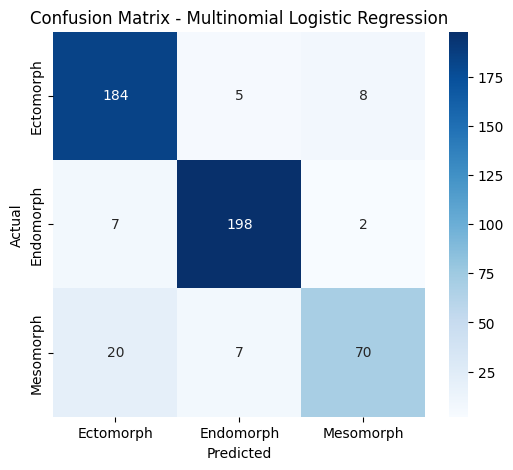

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=mlr_model.classes_,
            yticklabels=mlr_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Multinomial Logistic Regression")
plt.show()


Feature Coefficients:


,Ectomorph,Endomorph,Mesomorph
gender,0.602077,-0.461881,-0.140196
BMI,-0.614550,0.512499,0.102051
WaistHipRatio,-1.664831,3.371466,-1.706636
ShoulderWaistRatio,-1.451138,-1.745871,3.197008
ChestWaistRatio,-5.253769,-3.622775,8.876544
HeightWaistRatio,2.932480,-7.317008,4.384528
FrameIndex,1.640930,-0.926883,-0.714048


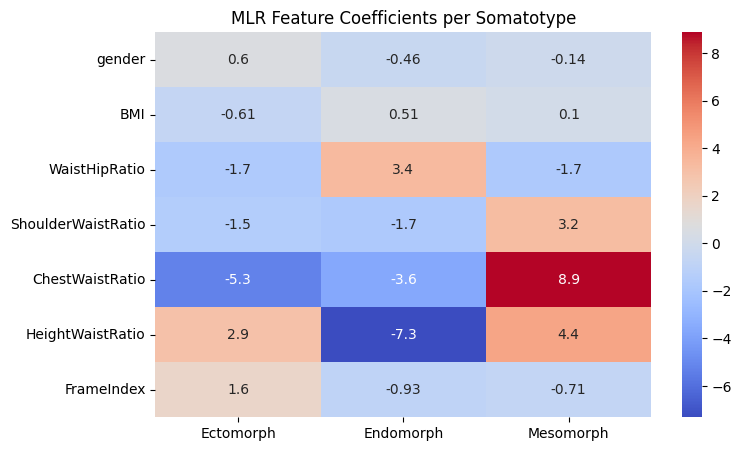

In [ ]:
coef_df = pd.DataFrame(
    mlr_model.coef_.T,
    index=features,
    columns=mlr_model.classes_
)

print("Feature Coefficients:")
display(coef_df)

# Optional: Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(coef_df, annot=True, cmap="coolwarm")
plt.title("MLR Feature Coefficients per Somatotype")
plt.show()


In [ ]:
import joblib

# Save the model
model_filename = "mlr_somatotype_model.pkl"
joblib.dump(mlr_model, model_filename)

print(f"Model saved as {model_filename}")


Model saved as mlr_somatotype_model.pkl
